In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from qkeras.utils import load_qmodel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
base_model = load_qmodel('modelo_estudiante_destilado_qat.h5')

In [3]:
# ═══════════════════════════════════════════════════════
# EVALUACIÓN FINAL — Holdout de tráfico real (10% original)
# Distribución natural desbalanceada: más representativa de producción
# ═══════════════════════════════════════════════════════

FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size',
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration',
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'
BATCH_SIZE = 128

df = pd.read_feather('Z:/TFG-Alvarez_Julian/IDS-IOT/data/df_binary_balanced.feather')
df['label_binario'] = (df['label'] != NOMBRE_CLASE_BENIGNA).astype(int)
print('Shape:', df.shape)
print(df['label_binario'].value_counts())

X = df[FEATURES_SELECCIONADAS].values
y = df['label_binario'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

del df; gc.collect()

df_holdout = pd.read_feather('Z:/TFG-Alvarez_Julian/IDS-IOT/data/test_real_traffic.feather')
df_holdout = df_holdout.replace([np.inf, -np.inf], np.nan)\
                        .dropna(subset=FEATURES_SELECCIONADAS + ['label'])

y_holdout = (df_holdout['label'] != NOMBRE_CLASE_BENIGNA).astype(int).values
X_holdout = scaler.transform(df_holdout[FEATURES_SELECCIONADAS].values)

print(f'Holdout — Total: {len(y_holdout):,}')
print(f'  Benigno   : {(y_holdout==0).sum():,} ({(y_holdout==0).mean():.2%})')
print(f'  Malicioso : {(y_holdout==1).sum():,} ({(y_holdout==1).mean():.2%})')


Shape: (1976752, 48)
label_binario
0    988376
1    988376
Name: count, dtype: int64
Holdout — Total: 4,668,658
  Benigno   : 109,819 (2.35%)
  Malicioso : 4,558,839 (97.65%)


In [4]:
def eval_with_threshold(y_true, probs, threshold, label):
    preds = (probs > threshold).astype(int)
    print(f'\n=== {label} (thr={threshold:.4f}) ===')
    print(classification_report(y_true, preds,
          target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítimo', 'Malicioso'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(label); plt.tight_layout(); plt.show()


36474/36474 [==============================] - 36s 971us/step

=== Holdout — Exp2 umbral 0.5 (thr=0.5000) ===
               precision    recall  f1-score   support

 Legítimo (0)     0.7007    0.9931    0.8216    109819
Malicioso (1)     0.9998    0.9898    0.9948   4558839

     accuracy                         0.9899   4668658
    macro avg     0.8502    0.9914    0.9082   4668658
 weighted avg     0.9928    0.9899    0.9907   4668658



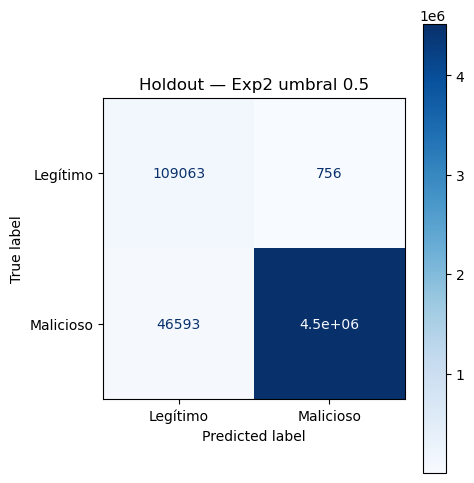

In [5]:
probs_h2 = base_model.predict(X_holdout, batch_size=BATCH_SIZE)

# Umbral 0.5 (default)
eval_with_threshold(y_holdout, probs_h2, 0.5,    'Holdout — Exp2 umbral 0.5')